# Hybrid glider vs. N-Sensor Defender: Unified SSG (`hybrid_glider_SSG_ms`)

Unified notebook merging four prior analyses for GameSec 2026 Problem A1b:

| Source | Scenario |
|---|---|
| `hybrid_glider_SSG_multisensor_hardened.ipynb` | Flat ground, headline SSE vs Naive vs Greedy (Sec 5.2) |
| `hybrid_glider_SSG_multisensor_landscape.ipynb` | Ridge dose-response, terrain masking (Sec 5.3) |
| `hybrid_glider_SSG_multisensor_landscape_skimming.ipynb` | Sea-skimming, hazard-aware powered DP (Sec 5.4) |
| `hybrid_glider_SSG_multisensor_landscape_skimming_with_nominal.ipynb` | + nominal-aware baseline for skimming |

## What changed in this unification

**1. Control-dwell-time fix (`K_HOLD_GLIDE`).** Each glide DP action holds the chosen `CL` for `K_HOLD_GLIDE` consecutive sub-RK4 transitions instead of re-choosing every grid step. The published every-step formulation produced phugoid-frequency chatter in the recovered glide trajectory that no amount of `(W_SMOOTH, W_SPEED)` weight tuning could suppress, because the chatter is a property of the dynamics and boundary condition, not of the cost. Sweeping `W_SMOOTH` from 0.1 to 10000 left curvature unchanged at the floor 0.078; `K_HOLD_GLIDE=4` cuts curvature ~5x to 0.015 at a modest cost increase. The powered phase keeps `K_HOLD_POW=1` because its low-speed launch dynamics under bang-bang thrust become non-integrable over multi-second control holds (gamma can wrap past 360 degrees in a single 4-second action).

**2. Handoff continuity.** `handoff_at` now returns the actual continuous `(z, h)` from the powered-DP `cont` dictionary; `attacker_BR` initializes the glide phase from these continuous coordinates (via `z_init`, `h_init`) instead of the nominal grid request. This eliminates the visible discontinuity at the switch point and the corresponding hazard-integration error at the closest-approach segment that previously inflated reported gaps.

**3. Unified powered DP.** Single `powered_dp` accepting `w_haz` and `w_alt`. Flat / dose-response scenarios call it once with `w_haz=0, w_alt=0` (energy-only, sensor-independent). The skimming scenario calls it per placement with `w_haz=1.0, w_alt=3e-3` (hazard-aware, per-placement re-solve).

**4. Scenario flag.** A single `SCENARIO` toggle selects `'flat'`, `'ridge_sweep'`, or `'skimming'`. Run sections 5–7 each set their own config and execute end-to-end.

In [1]:
import math, time, heapq, itertools
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Constants

All scenario-independent constants. Scenario-dependent values (`D_SITES`, `RIDGE_HR`, `POW_GRID`, etc.) are set in Section 2 below.

In [2]:
# --- physics / vehicle ---
G, RHO       = 9.81, 1.225
M, S, CD     = 1.5, 0.1, 0.025
CL_DISCRETE  = tuple(np.linspace(0.1, 1.5, 10))
V_STALL, V_MAX = 14.0, 100.0
T_MAX        = 25.0
THRUST_LEVELS = (0.0, T_MAX)

# --- mission geometry ---
Z_LAUNCH, H_LAUNCH   = 0.0, 0.0
Z_GOAL,   H_GOAL     = 2500.0, 0.0
DT_GLIDE, DT_POW     = 1.0, 1.0     # both 1 s so dt*v ~ dz/2 and snap advances
V_MAX_GLIDE          = 60.0

# Launch state (overridden per scenario in configure_scenario).
# Defaults to the steep climb-out used by the hardened (flat) pipeline. The skimming
# and ridge-sweep scenarios reset GAM_LAUNCH to 10 deg, matching their original
# calibrations. Each scenario therefore reproduces its source notebook's launch
# geometry; the rest of the pipeline (K_HOLD_GLIDE, handoff continuity, unified
# powered DP) is consistent across all three.
V_LAUNCH    = V_STALL
GAM_LAUNCH  = math.radians(45.0)

# --- threat model (Poisson channel intensities, calibrated; see Sec 3.3 of paper) ---
LAM_DOPPLER  = 4.5e2
LAM_RCS      = 6.0e3
SIGMA0, SIGMA_MIN = 1.0, 0.1
LAM_ACOUSTIC = 2.4e-3     # hardened/landscape calibration; skimming raises this in Sec 7
N_ACOUSTIC   = 4
R_FLOOR      = 10.0

# --- objectives ---
A1_PD, A2_T   = 1.0, 0.002
B1_PD, B2_COV = 1.0, 0.5

# --- glide cost shaping ---
W_TIME_GLIDE = 0.005
W_SMOOTH     = 0.1
W_SPEED      = 1.5
H_CLEAR      = 15.0
Z_FLARE      = 300.0
H_HEADROOM_G = 100.0

# --- powered cost shaping ---
W_TIME_POW   = 1.0
W_FUEL_POW   = 0.1
# Hazard-aware powered DP weights (skimming scenario activates these):
W_HAZ_POW    = 1.0
W_ALT_POW    = 3.0e-3

# --- switch / BR ---
V_SW_FLOOR   = 16.0
N_SWITCH     = 12
TIE_EPS      = 1e-3

# --- K-HOLD CONTROL DWELL TIME (principal methodology fix) ---
# Each DP action holds the chosen control for K consecutive transitions.
# The fix targets phugoid-frequency chatter in the GLIDE phase (slow dynamics).
# The POWERED phase has fast bang-bang thrust + low-speed launch where holding a
# control for several seconds blows up the dynamics (gamma can wrap past 360 deg
# in a single action), so we keep its per-step behavior.
#   K_HOLD_GLIDE = 4: glide chatter drops ~5x, modest cost increase (diagnostic sweep).
#   K_HOLD_POW   = 1: legacy per-step behavior, required for launch-transient stability.
K_HOLD_GLIDE = 4
K_HOLD_POW   = 1

# --- terrain default (overridden per scenario) ---
RIDGE_HR     = 0.0
RIDGE_ZR     = 1500.0
RIDGE_W      = 250.0
MAST         = 0.0
ACOUST_OCC   = 0.2
TERR_CLEAR   = 5.0

print(f"Imports OK. Defaults loaded. K_HOLD_POW={K_HOLD_POW}, K_HOLD_GLIDE={K_HOLD_GLIDE}.")

Imports OK. Defaults loaded. K_HOLD_POW=1, K_HOLD_GLIDE=4.


## 2. Scenario configuration

Set `SCENARIO` to one of `'flat'`, `'ridge_sweep'`, or `'skimming'`. Run sections 5, 6, and 7 below check `SCENARIO` and execute accordingly. The default (`'all'`) runs every section in sequence.

In [3]:
SCENARIO = 'all'    # 'flat' | 'ridge_sweep' | 'skimming' | 'all'

def configure_scenario(name):
    '''Set scenario-dependent globals. Returns the active D_SITES grid.'''
    g = globals()
    if name == 'flat':
        g['GAM_LAUNCH']  = math.radians(45.0)   # steep climb-out (hardened convention)
        g['N_SENSORS']   = 2
        g['R_PERIM']     = 2000.0
        g['D_SITES']     = np.arange(Z_GOAL - g['R_PERIM'], Z_GOAL + 1, 250.0)
        g['CORRIDOR_Z0'] = 500.0
        g['R_DET']       = 600.0
        g['RIDGE_HR']    = 0.0
        g['RIDGE_ZR']    = 1500.0
        g['RIDGE_W']     = 250.0
        g['MAST']        = 0.0
        g['ACOUST_OCC']  = 1.0          # no terrain, no occlusion
        # Powered DP mode: energy-only, solved once. (w_haz=0, w_alt=0)
        g['POW_W_HAZ']   = 0.0
        g['POW_W_ALT']   = 0.0
        g['POW_GRID']    = dict(dz=25.0, dh=10.0, dv=3.0, dgam=math.radians(4.0),
                                 zmax=300.0, hmax=200.0)
        g['RANK_GRID']   = dict(dz=100.0, dh=10.0, dv=4.0, dgam=math.radians(4.0))
        g['FINAL_GRID']  = dict(dz=50.0,  dh=5.0,  dv=2.0, dgam=math.radians(2.0))
        # In flat mode the switch is launch-confined (small powered phase).
        g['SWITCH_Z_RANGE'] = (100.0, 300.0, 50.0)
        g['SWITCH_H_RANGE'] = (40.0, 160.0, 20.0)
    elif name == 'ridge_sweep':
        g['GAM_LAUNCH']  = math.radians(10.0)   # shallow climb-out (landscape convention)
        g['N_SENSORS']   = 2
        g['R_PERIM']     = 2000.0
        g['D_SITES']     = np.arange(Z_GOAL - g['R_PERIM'], Z_GOAL + 1, 250.0)
        g['CORRIDOR_Z0'] = 500.0
        g['R_DET']       = 600.0
        g['RIDGE_HR']    = 60.0          # initial; sweep changes this
        g['RIDGE_ZR']    = 1500.0
        g['RIDGE_W']     = 250.0
        g['MAST']        = 0.0
        g['ACOUST_OCC']  = 0.2
        g['POW_W_HAZ']   = 0.0           # still energy-only powered phase
        g['POW_W_ALT']   = 0.0
        g['POW_GRID']    = dict(dz=25.0, dh=10.0, dv=3.0, dgam=math.radians(4.0),
                                 zmax=300.0, hmax=200.0)
        g['RANK_GRID']   = dict(dz=100.0, dh=10.0, dv=4.0, dgam=math.radians(4.0))
        g['FINAL_GRID']  = dict(dz=50.0,  dh=5.0,  dv=2.0, dgam=math.radians(2.0))
        g['SWITCH_Z_RANGE'] = (100.0, 300.0, 50.0)
        g['SWITCH_H_RANGE'] = (40.0, 160.0, 20.0)
    elif name == 'skimming':
        g['GAM_LAUNCH']  = math.radians(10.0)   # shallow climb-out (skimming convention)
        g['N_SENSORS']   = 1
        g['D_SITES']     = np.linspace(1500.0, 2500.0, 21)
        g['CORRIDOR_Z0'] = 1500.0
        g['R_DET']       = 600.0
        g['RIDGE_HR']    = 100.0
        g['RIDGE_ZR']    = 1100.0        # mid-corridor, on launch side of all defenders
        g['RIDGE_W']     = 350.0
        g['MAST']        = 0.0
        g['ACOUST_OCC']  = 0.05          # strong attenuation when occluded
        # Powered DP mode: hazard-aware, per-placement re-solve.
        g['POW_W_HAZ']   = 1.0
        g['POW_W_ALT']   = 3.0e-3
        # Powered grid is corridor-wide for skimming (switch can fire late).
        g['POW_GRID']    = dict(dz=25.0, dh=20.0, dv=5.0, dgam=math.radians(2.5),
                                 zmax=Z_GOAL, hmax=180.0)
        g['RANK_GRID']   = dict(dz=100.0, dh=25.0, dv=8.0, dgam=math.radians(12.0))
        g['FINAL_GRID']  = dict(dz=75.0,  dh=20.0, dv=6.0, dgam=math.radians(10.0))
        # Switch is corridor-wide (early to late).
        g['SWITCH_Z_RANGE'] = (100.0, Z_GOAL - 100.0, 200.0)
        g['SWITCH_H_RANGE'] = (20.0, 200.0, 60.0)  # discrete; switch candidates filter further
        # Headroom relaxed so glide can zoom-climb over the ridge if needed.
        g['H_HEADROOM_G'] = 250.0
    else:
        raise ValueError(f"unknown scenario {name!r}")
    n_combos = len(list(itertools.combinations(g['D_SITES'], g['N_SENSORS'])))
    print(f"[scenario={name}] N_SENSORS={g['N_SENSORS']}, |D_SITES|={len(g['D_SITES'])}, "
          f"C(|D|,N)={n_combos}")
    print(f"   ridge h_r={g['RIDGE_HR']} m, z_r={g['RIDGE_ZR']} m, w={g['RIDGE_W']} m, "
          f"acoust_occ={g['ACOUST_OCC']}")
    print(f"   powered DP mode: w_haz={g['POW_W_HAZ']}, w_alt={g['POW_W_ALT']} "
          f"({'energy-only (1 solve)' if g['POW_W_HAZ']==0 else 'hazard-aware (per-placement)'})")
    print(f"   K_HOLD_POW={K_HOLD_POW}, K_HOLD_GLIDE={K_HOLD_GLIDE}")

## 3. Dynamics

Longitudinal point-mass model with thrust `T`, lift coefficient `CL`, fixed drag `CD`. State `(z, h, v, gamma)`. RK4 integrator.

In [4]:
def eom(v, gamma, CL, T):
    s, co = math.sin(gamma), math.cos(gamma)
    q     = 0.5 * RHO * v * v * S
    return (v * co,
            v * s,
            -G * s - q * CD / M + T / M,
             q * CL / (M * v) - G * co / v)

def rk4(z, h, v, gamma, CL, dt, T):
    k1 = eom(v, gamma, CL, T)
    k2 = eom(v + k1[2]*dt/2, gamma + k1[3]*dt/2, CL, T)
    k3 = eom(v + k2[2]*dt/2, gamma + k2[3]*dt/2, CL, T)
    k4 = eom(v + k3[2]*dt,   gamma + k3[3]*dt,   CL, T)
    return (z + dt/6*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0]),
            h + dt/6*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1]),
            v + dt/6*(k1[2] + 2*k2[2] + 2*k3[2] + k4[2]),
            gamma + dt/6*(k1[3] + 2*k2[3] + 2*k3[3] + k4[3]))

## 4. Terrain, line-of-sight, threat model

Gaussian ridge `TERR(z)`. `visible(...)` performs a skyline LOS test in the longitudinal plane. The threat model is multi-sensor Poisson fusion: per-channel intensities sum over sensors; final detection probability is `1 - exp(-Σhazard·dt)`. Radar (Doppler + RCS) hard-gates on LOS; acoustic attenuates by `ACOUST_OCC` (diffraction). When `RIDGE_HR=0` the model reduces to flat ground exactly.

In [5]:
# --- terrain & LOS ---
def TERR(z):
    return RIDGE_HR * math.exp(-((z - RIDGE_ZR) / RIDGE_W) ** 2)

def sens_h(zd):
    return TERR(zd) + MAST

def visible(zd, z, h, n=24):
    sh = sens_h(zd)
    if abs(z - zd) < 1e-6: return True
    for i in range(1, n):
        t     = i / n
        zp    = zd + t * (z - zd)
        h_ray = sh + t * (h - sh)
        if h_ray < TERR(zp) - 1e-9: return False
    return True

def terrain_floor(z):
    t = TERR(z)
    return (t + TERR_CLEAR) if t >= 0.5 else 0.0

# --- per-channel hazard rates with LOS gating ---
def _range(z, h, sensor):
    r = math.hypot(z - sensor[0], h - sensor[1])
    return r if r > R_FLOOR else R_FLOOR

def doppler_rate(z, h, v, gamma, sensor):
    zd = sensor[0]
    if not visible(zd, z, h): return 0.0
    sh = sens_h(zd); r = _range(z, h, (zd, sh))
    dz, dh = z - zd, h - sh
    vr = (v * math.cos(gamma) * dz + v * math.sin(gamma) * dh) / r
    return LAM_DOPPLER * vr * vr / r**4

def rcs_rate(z, h, v, gamma, sensor):
    zd = sensor[0]
    if not visible(zd, z, h): return 0.0
    sh = sens_h(zd); r = _range(z, h, (zd, sh))
    ez, eh = (zd - z) / r, (sh - h) / r
    c = ez * (-math.sin(gamma)) + eh * math.cos(gamma)
    sigma = SIGMA_MIN + (SIGMA0 - SIGMA_MIN) * c * c
    return LAM_RCS * sigma / r**4

def radar_rate(z, h, v, gamma, sensor):
    return doppler_rate(z, h, v, gamma, sensor) + rcs_rate(z, h, v, gamma, sensor)

def acoustic_rate(z, h, v, sensor):
    zd = sensor[0]; sh = sens_h(zd); r = _range(z, h, (zd, sh))
    base = LAM_ACOUSTIC * v**N_ACOUSTIC / (r * r)
    return base * (1.0 if visible(zd, z, h) else ACOUST_OCC)

# --- hazard integrators (used by BR scorer; integrate fused rate over substepped paths) ---
def hazard_glide(pts, sensors, dt_sub):
    return sum(
        sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        for (z, h, v, g, _T) in pts[:-1]
    )

def hazard_powered(pts, sensors, dt_sub):
    cost = 0.0
    for (z, h, v, g, T) in pts[:-1]:
        cost += sum(radar_rate(z, h, v, g, s) for s in sensors) * dt_sub
        if T > 0:
            cost += sum(acoustic_rate(z, h, v, s) for s in sensors) * dt_sub
    return cost

def pod_from_hazard(hz):
    return 1.0 - math.exp(-hz)

## 5. State grids, snapping, clearance floor

In [6]:
def glide_grid(z_sw, h_sw, dz, dh, dv, dgam, hh):
    Z  = np.arange(z_sw, Z_GOAL + dz, dz)
    H  = np.arange(0.0, max(h_sw + hh, POW_GRID['hmax']) + dh, dh)
    Vv = np.arange(V_STALL, V_MAX_GLIDE + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(45) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def pow_grid(dz, dh, dv, dgam, zmax, hmax):
    Z  = np.arange(0.0, zmax + dz, dz)
    H  = np.arange(0.0, hmax + dh, dh)
    Vv = np.arange(V_STALL, V_MAX + dv, dv)
    Gg = np.arange(math.radians(-90), math.radians(90) + dgam, dgam)
    return dict(Z0=Z[0], H0=H[0], V0=Vv[0], G0=Gg[0],
                dz=dz, dh=dh, dv=dv, dgam=dgam,
                NZ=len(Z), NH=len(H), NV=len(Vv), NG=len(Gg),
                Gam=Gg, V=Vv, Z=Z, H=H)

def snap(gr, z, h, v, gamma):
    iz = int(round((z - gr['Z0']) / gr['dz']))
    ih = int(round((h - gr['H0']) / gr['dh']))
    iv = int(round((v - gr['V0']) / gr['dv']))
    ig = int(round((gamma - gr['G0']) / gr['dgam']))
    if 0 <= iz < gr['NZ'] and 0 <= ih < gr['NH'] and 0 <= iv < gr['NV'] and 0 <= ig < gr['NG']:
        return (iz, ih, iv, ig)
    return None

def minclear(z, hc, zf):
    d = Z_GOAL - z
    if d >= zf: return hc
    if d <= 0:  return 0.0
    return hc * d / zf

## 6. Powered phase: Dijkstra DP (unified, K-hold)

Each action holds `(CL, T)` for `K_HOLD_POW` consecutive `DT_POW`-second sub-RK4 transitions. Per-action cost accumulates time, fuel, hazard, and altitude penalty across the K substeps; one action advances the state by `K_HOLD * DT_POW` seconds.

Two modes via `(w_haz, w_alt)`:
- `w_haz=0, w_alt=0`: energy-only. Trajectory independent of sensor placement; solved once.
- `w_haz>0`: hazard-aware. Trajectory depends on sensors; re-solved per placement.

The `handoff_at` function returns the actual continuous `(z, h)` from `cont` so the glide phase initializes from the true continuous state.

In [7]:
def powered_dp(gr, sensors, w_time=W_TIME_POW, w_fuel=W_FUEL_POW,
               w_haz=0.0, w_alt=0.0, K=None):
    '''Unified powered-phase Dijkstra DP with K_HOLD_POW control dwell.
    If w_haz=0 and w_alt=0, sensors is unused (energy-only mode).
    Otherwise sensors must be the active placement (hazard-aware mode).'''
    if K is None: K = K_HOLD_POW
    s0 = snap(gr, Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)
    V = {s0: 0.0}; prev = {}; cont = {s0: (Z_LAUNCH, H_LAUNCH, V_LAUNCH, GAM_LAUNCH)}
    heap = [(0.0, 0, s0)]; cnt = 1
    hmax = gr['H'][-1]
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        z, h, v, gm = cont[s]
        for T in THRUST_LEVELS:
            for CL in CL_DISCRETE:
                # Hold (CL, T) for K consecutive RK4 transitions; accumulate cost over substeps.
                zz, hh_, vv, gg = z, h, v, gm
                step_cost = 0.0
                feasible  = True
                for _ in range(K):
                    znn, hnn, vnn, gnn = rk4(zz, hh_, vv, gg, CL, DT_POW, T)
                    if hnn < 0 or znn < 0 or vnn < V_STALL or hnn > hmax:
                        feasible = False; break
                    if hnn < terrain_floor(znn):
                        feasible = False; break
                    base = w_time * DT_POW + w_fuel * T * DT_POW
                    haz_inc = 0.0
                    if w_haz > 0.0:
                        haz_inc += sum(radar_rate(znn, hnn, vnn, gnn, sn_) for sn_ in sensors) * DT_POW
                        if T > 0:
                            haz_inc += sum(acoustic_rate(znn, hnn, vnn, sn_) for sn_ in sensors) * DT_POW
                    alt_pen = w_alt * hnn * DT_POW
                    step_cost += base + w_haz * haz_inc + alt_pen
                    zz, hh_, vv, gg = znn, hnn, vnn, gnn
                if not feasible: continue
                sn = snap(gr, zz, hh_, vv, gg)
                if sn is None: continue
                nc = c + step_cost
                if nc < V.get(sn, 1e18):
                    V[sn] = nc
                    prev[sn] = (s, CL, T)
                    cont[sn] = (zz, hh_, vv, gg)
                    heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0

def handoff_at(gr, V, cont, z_sw, h_sw):
    '''Return the lowest-cost grid state at requested (z_sw, h_sw) restricted to
    non-climbing flight-path angle, with the ACTUAL continuous (z, h) for glide init.'''
    izp = int(round((z_sw - gr['Z0']) / gr['dz']))
    ihp = int(round((h_sw - gr['H0']) / gr['dh']))
    if not (0 <= izp < gr['NZ'] and 0 <= ihp < gr['NH']): return None
    best, bv = None, 1e18
    for iv in range(gr['NV']):
        for ig in range(gr['NG']):
            if gr['Gam'][ig] > 1e-9: continue  # only level/descending at handoff
            s = (izp, ihp, iv, ig)
            if s in V and V[s] < bv: bv, best = V[s], s
    if best is None: return None
    z, h, v, g = cont[best]
    return dict(state=best, z=z, h=h, v=v, gamma=g, cost=bv)

## 7. Glide phase: regularized Dijkstra DP (unified, K-hold)

Each action holds `CL` for `K_HOLD_GLIDE` consecutive `DT_GLIDE`-second transitions. Hazard cost accumulates over the K substeps; the smoothness penalty `w_smooth * |Δγ| + w_speed * |Δv|` is paid once per action (over the full K-step change). The control-rate effect that suppresses phugoid chatter comes from forcing each CL to live across `K_HOLD` seconds rather than being free at every grid step.

Terrain awareness: ground-clearance floor is `max(minclear(z), terrain_floor(z))`. Handoff continuity: `z_init` and `h_init` override `cont[s0]` so the trajectory starts from the actual continuous powered-DP state.

In [8]:
def glide_dp(gr, z_sw, h_sw, v_sw, g_sw, sensors, w_time, w_smooth, w_speed,
             hc, zf, hh, use_radar=True, z_init=None, h_init=None, K=None):
    '''Unified glide-phase Dijkstra DP with K_HOLD_GLIDE dwell + terrain + handoff continuity.'''
    if K is None: K = K_HOLD_GLIDE
    s0 = snap(gr, z_sw, h_sw, v_sw, g_sw)
    if s0 is None: return None
    izg = gr['NZ'] - 1
    z_c = z_init if z_init is not None else z_sw
    h_c = h_init if h_init is not None else h_sw
    V = {s0: 0.0}; prev = {}; cont = {s0: (z_c, h_c, v_sw, g_sw)}
    heap = [(0.0, 0, s0)]; cnt = 1
    ceil = gr['H'][-1]
    goal = None
    while heap:
        c, _, s = heapq.heappop(heap)
        if c > V.get(s, 1e18) + 1e-9: continue
        if s[0] == izg and s[1] == 0: goal = s; break
        z, h, v, gm = cont[s]
        for CL in CL_DISCRETE:
            zz, hh_, vv, gg = z, h, v, gm
            step_cost = 0.0
            feasible  = True
            for _ in range(K):
                znn, hnn, vnn, gnn = rk4(zz, hh_, vv, gg, CL, DT_GLIDE, 0.0)
                if vnn < V_STALL or hnn > ceil:
                    feasible = False; break
                tf = max(minclear(znn, hc, zf), terrain_floor(znn))
                if hnn < tf - 1e-9:
                    feasible = False; break
                pr = sum(radar_rate(zz, hh_, vv, gg, sen) for sen in sensors) if use_radar else 0.0
                step_cost += pr * DT_GLIDE + w_time * DT_GLIDE
                zz, hh_, vv, gg = znn, hnn, vnn, gnn
            if not feasible: continue
            sn = snap(gr, zz, hh_, vv, gg)
            if sn is None: continue
            # Smoothness paid once per action over the full K-step change.
            nc = c + step_cost + w_smooth * abs(gg - gm) + w_speed * abs(vv - v)
            if nc < V.get(sn, 1e18):
                V[sn] = nc
                prev[sn] = (s, CL)
                cont[sn] = (zz, hh_, vv, gg)
                heapq.heappush(heap, (nc, cnt, sn)); cnt += 1
    return V, prev, cont, s0, goal

## 8. Trajectory reconstruction

`reconstruct` walks `prev` back from the goal node and replays each action by `substeps`-substepped RK4 to produce a smooth (z, h, v, γ, T) trace. With `K > 1` each action is replayed K times so the trace stays at native resolution (caller passes `K_HOLD_POW` for powered, `K_HOLD_GLIDE` for glide).

In [9]:
def reconstruct(prev, cont, s_goal, s0, dt, T_is_stored, substeps=8, K=1):
    '''Replay action sequence at `substeps` sub-RK4 per native step, K times per action.
    Caller should pass K=K_HOLD_POW for powered, K=K_HOLD_GLIDE for glide.'''
    seq = []; s = s_goal
    while s != s0 and s in prev:
        e = prev[s]
        if T_is_stored: ps, CL, Tt = e
        else:           ps, CL = e; Tt = 0.0
        seq.append((CL, Tt)); s = ps
    seq.reverse()
    z, h, v, g = cont[s0]
    sub = dt / substeps
    pts = [(z, h, v, g, 0.0)]
    for CL, Tt in seq:
        for _ in range(K):
            for _ in range(substeps):
                z, h, v, g = rk4(z, h, v, g, CL, sub, Tt)
                pts.append((z, h, v, g, Tt))
    return pts

def count_steps(prev, s0, s_goal):
    '''Native action count along the path (each action spans K * dt seconds of flight).'''
    n, s = 0, s_goal
    while s != s0 and s in prev:
        n += 1; s = prev[s][0]
    return n

## 9. Coverage, defender objective, baseline placements

In [10]:
def coverage(sensors):
    '''Union of coverage intervals across all sensors, normalized by corridor length.'''
    intervals = []
    for s in sensors:
        lo = max(CORRIDOR_Z0, s[0] - R_DET)
        hi = min(Z_GOAL,      s[0] + R_DET)
        if hi > lo: intervals.append((lo, hi))
    if not intervals: return 0.0
    intervals.sort()
    merged = [list(intervals[0])]
    for lo, hi in intervals[1:]:
        if lo <= merged[-1][1]: merged[-1][1] = max(merged[-1][1], hi)
        else:                   merged.append([lo, hi])
    total = sum(hi - lo for lo, hi in merged)
    return total / (Z_GOAL - CORRIDOR_Z0)

def J_D(P_D, sensors):
    return B1_PD * P_D + B2_COV * coverage(sensors)

def naive_placement(n):
    '''Evenly-spaced sensors from D_SITES (by index).'''
    if n >= len(D_SITES):
        return [(float(z), 0.0) for z in D_SITES]
    idx = np.round(np.linspace(0, len(D_SITES) - 1, n)).astype(int)
    return [(float(D_SITES[i]), 0.0) for i in sorted(set(idx))]

def greedy_coverage_placement(n):
    '''Greedy submodular coverage maximization.'''
    placed = []
    available = [float(z) for z in D_SITES]
    for _ in range(n):
        best_site, best_cov = None, -1.0
        for z in available:
            c = coverage(placed + [(z, 0.0)])
            if c > best_cov: best_cov, best_site = c, z
        placed.append((best_site, 0.0))
        available = [z for z in available if z != best_site]
    return placed

def _sensors_key(sensors):
    return tuple(sorted((round(s[0]), round(s[1])) for s in sensors))

## 10. Switch candidates and attacker best response

`switch_candidates` enumerates a discrete grid of switch points and rejects infeasible / underspeed ones. `attacker_BR` evaluates a placement by solving the glide DP from each candidate, scoring each via Poisson-fused hazard, and applying the Strong Stackelberg tie-break (among `J_A`-tied switches, the attacker picks the highest `P_D`).

In [11]:
def switch_candidates(grp, Vp, contp):
    raw = []
    z_lo, z_hi, z_step = SWITCH_Z_RANGE
    h_lo, h_hi, h_step = SWITCH_H_RANGE
    z_grid = list(np.arange(z_lo, z_hi + 1, z_step))
    h_grid = list(np.arange(h_lo, h_hi + 1, h_step))
    for z_sw in z_grid:
        for h_sw in h_grid:
            if h_sw < terrain_floor(z_sw) + 5.0: continue
            ho = handoff_at(grp, Vp, contp, z_sw, h_sw)
            if ho is None or ho['v'] < V_SW_FLOOR: continue
            raw.append((float(z_sw), float(h_sw), ho))
    if len(raw) > N_SWITCH:
        idx = np.linspace(0, len(raw) - 1, N_SWITCH).round().astype(int)
        return [raw[i] for i in sorted(set(idx))]
    return raw

def attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands, grid=None, substeps=6,
                use_radar=True):
    '''Best response to a sensor array. Returns the winning switch + trajectory.'''
    grid = grid or RANK_GRID
    evals = []
    for z_sw, h_sw, ho in cands:
        # Continuity fix: initialize glide from actual continuous state of powered DP.
        z_hand, h_hand = ho['z'], ho['h']
        gr = glide_grid(z_hand, h_hand, hh=H_HEADROOM_G, **grid)
        out = glide_dp(gr, z_hand, h_hand, ho['v'], ho['gamma'], sensors,
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G,
                       use_radar=use_radar)
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        glide_pts = reconstruct(prev, cont, best, s0, DT_GLIDE, False,
                                substeps=substeps, K=K_HOLD_GLIDE)
        pow_pts   = reconstruct(prevp, contp, ho['state'], s0p, DT_POW, True,
                                substeps=substeps, K=K_HOLD_POW)
        hz = (hazard_glide(glide_pts, sensors, DT_GLIDE/substeps)
              + hazard_powered(pow_pts, sensors, DT_POW/substeps))
        P_D = pod_from_hazard(hz)
        T = (count_steps(prevp, s0p, ho['state']) * K_HOLD_POW * DT_POW
             + count_steps(prev,  s0,  best)       * K_HOLD_GLIDE * DT_GLIDE)
        J_A = A1_PD * P_D + A2_T * T
        evals.append(dict(J_A=J_A, P_D=P_D, T=T, hz=hz,
                          z_sw=z_hand, h_sw=h_hand,
                          ho=ho, glide_pts=glide_pts, pow_pts=pow_pts))
    if not evals: return None
    jmin = min(e['J_A'] for e in evals)
    tied = [e for e in evals if e['J_A'] <= jmin + TIE_EPS]
    return max(tied, key=lambda e: e['P_D'])

## 11. Shared SSE-vs-baselines driver

`run_sse_vs_baselines` is the workhorse used by Sections 5 (flat) and 6 (ridge sweep). It performs:

1. Solve the powered DP (once if energy-only, else per-placement during enumeration).
2. Build switch candidates.
3. Enumerate `C(|D|, N)` placements; compute the attacker BR for each.
4. Pick SSE as `argmax J_D`. Compute Naive and Greedy placements; score them.
5. Re-evaluate SSE / Naive / Greedy on `FINAL_GRID`.

Returns a dict with the three scored placements plus the full sweep for diagnostics.

In [12]:
def run_sse_vs_baselines(scenario_label='flat', verbose=True, top_k=10):
    """Coarse-screen + fine-evaluate top-k + baselines, pick fine-argmax SSE.

    The published every-step formulation chose SSE from the coarse-grid sweep
    and then re-evaluated only SSE/Naive/Greedy on the fine grid. Several
    placements (notably those with a sensor at the goal) exhibited coarse-to-fine
    J_D inversions large enough to flip the SSE identity, producing the
    contradiction SSE J_D < Naive J_D. This routine fixes that by:
      (1) coarse-sweeping all C(|D|, N) placements as before;
      (2) selecting the top-k by coarse J_D as fine-evaluation candidates;
      (3) forcing Naive and Greedy into the candidate set;
      (4) re-evaluating all candidates on FINAL_GRID;
      (5) SSE = argmax fine J_D among candidates.
    """
    t0 = time.time()
    # --- 1. powered DP (energy-only branch: solve once; else inside the loop) ---
    grp = pow_grid(**POW_GRID)
    energy_only = (POW_W_HAZ == 0.0 and POW_W_ALT == 0.0)
    if energy_only:
        Vp, prevp, contp, s0p = powered_dp(grp, sensors=[],
                                            w_haz=0.0, w_alt=0.0)
        cands = switch_candidates(grp, Vp, contp)
        if verbose:
            print(f"  [energy-only powered DP, 1 solve]: {len(Vp)} states, "
                  f"{len(cands)} switch candidates ({time.time()-t0:.1f}s)")
    else:
        if verbose:
            print(f"  [hazard-aware powered DP: re-solved per placement]")

    # --- 2. enumerate placements at coarse RANK_GRID ---
    sweep = []
    for combo in itertools.combinations(D_SITES, N_SENSORS):
        sensors = [(float(zd), 0.0) for zd in combo]
        if energy_only:
            grp_loc, Vp_loc, prevp_loc, contp_loc, s0p_loc, cands_loc = (
                grp, Vp, prevp, contp, s0p, cands)
        else:
            grp_loc = pow_grid(**POW_GRID)
            Vp_loc, prevp_loc, contp_loc, s0p_loc = powered_dp(
                grp_loc, sensors,
                w_haz=POW_W_HAZ, w_alt=POW_W_ALT)
            cands_loc = switch_candidates(grp_loc, Vp_loc, contp_loc)
        if not cands_loc: continue
        br = attacker_BR(sensors, grp_loc, Vp_loc, prevp_loc, contp_loc, s0p_loc, cands_loc)
        if br is None: continue
        sweep.append(dict(
            sensors=sensors,
            sensor_label=str([int(s[0]) for s in sensors]),
            P_D=br['P_D'], T=br['T'], cov=coverage(sensors),
            J_D=J_D(br['P_D'], sensors), br=br,
            grp=grp_loc, Vp=Vp_loc, prevp=prevp_loc,
            contp=contp_loc, s0p=s0p_loc, cands=cands_loc,
        ))
    if not sweep:
        raise RuntimeError("Empty sweep: no feasible attacker BR for any placement.")
    if verbose:
        print(f"  coarse sweep enumerated {len(sweep)} placements in {time.time()-t0:.1f}s")

    # --- 3. build fine-eval candidate set: top-k by coarse J_D + naive + greedy ---
    nv_sensors = naive_placement(N_SENSORS)            # already [(z, 0.0), ...]
    gd_sensors = greedy_coverage_placement(N_SENSORS)  # already [(z, 0.0), ...]
    sweep_sorted = sorted(sweep, key=lambda r: -r['J_D'])
    candidates = list(sweep_sorted[:top_k])
    cand_keys = set(_sensors_key(c['sensors']) for c in candidates)
    forced_added = []
    for ref_sensors, ref_name in [(nv_sensors, 'naive'), (gd_sensors, 'greedy')]:
        ref_key = _sensors_key(ref_sensors)
        if ref_key not in cand_keys:
            hit = next((r for r in sweep if _sensors_key(r['sensors']) == ref_key), None)
            if hit is not None:
                candidates.append(hit)
                cand_keys.add(ref_key)
                forced_added.append(ref_name)
    if verbose:
        rk_coarse_J = [r['J_D'] for r in sweep_sorted[:top_k]]
        print(f"  candidates: top-{top_k} by coarse J_D"
              f"{' (range [' + format(min(rk_coarse_J),'.3f') + ', ' + format(max(rk_coarse_J),'.3f') + '])' if rk_coarse_J else ''}"
              f"{', forced ' + '+'.join(forced_added) if forced_added else ''} "
              f"= {len(candidates)} placements")

    # --- 4. fine-evaluate all candidates ---
    t_fine = time.time()
    fine_candidates = []
    for r in candidates:
        br_f = attacker_BR(r['sensors'], r['grp'], r['Vp'], r['prevp'], r['contp'],
                         r['s0p'], r['cands'], grid=FINAL_GRID, substeps=8)
        if br_f is None: continue
        fine_candidates.append(dict(r, P_D=br_f['P_D'], T=br_f['T'],
                                     J_D=J_D(br_f['P_D'], r['sensors']), br=br_f))
    if not fine_candidates:
        raise RuntimeError("No candidates feasible at FINAL_GRID.")
    if verbose:
        print(f"  fine-evaluated {len(fine_candidates)} candidates in {time.time()-t_fine:.1f}s")

    # --- 5. SSE = argmax fine J_D among candidates ---
    sse_f = max(fine_candidates, key=lambda r: r['J_D'])

    # --- 6. naive + greedy (read from fine_candidates) ---
    def find_in_fine(sensors_):
        key = _sensors_key(sensors_)
        return next((r for r in fine_candidates if _sensors_key(r['sensors']) == key), None)
    naive_f  = find_in_fine(nv_sensors)
    greedy_f = find_in_fine(gd_sensors)

    if verbose:
        print(f"  total = {time.time()-t0:.1f}s")
        for name, r in [('SSE', sse_f), ('Naive', naive_f), ('Greedy', greedy_f)]:
            if r:
                print(f"  {name:7s} sensors={r['sensor_label']}  "
                      f"P_D={r['P_D']:.3f}  cov={r['cov']:.2f}  J_D={r['J_D']:.3f}")
            else:
                print(f"  {name:7s} (not in candidate set)")
    return dict(sse=sse_f, naive=naive_f, greedy=greedy_f,
                sweep=sweep, scenario=scenario_label,
                grp=grp if energy_only else None,
                Vp=Vp  if energy_only else None,
                prevp=prevp if energy_only else None,
                contp=contp if energy_only else None,
                s0p=s0p if energy_only else None,
                cands=cands if energy_only else None,
                energy_only=energy_only)

## 12. Shared plotting helpers

In [13]:
# Color palette (consistent across scenarios)
NA_C, AC_C, COV_C  = '#E07B39', '#3A86FF', '#2a9d8f'
SSE_C, NOM_C, MID_C = 'crimson', '#E07B39', 'gray'
SAVE_KW = dict(dpi=150, bbox_inches='tight')

def plot_trajectory(ax, result, title=None, show_terrain=True, label_prefix=''):
    '''Plot the BR powered+glide trajectory along with sensors and terrain.'''
    sse = result
    if show_terrain and RIDGE_HR > 0:
        zline = np.linspace(0, Z_GOAL, 400)
        hline = np.array([TERR(z) for z in zline])
        ax.fill_between(zline, 0, hline, color='#8d6e63', alpha=0.55, zorder=1, label='terrain')
        ax.plot(zline, hline, color='#5d4037', lw=1.0, zorder=1)
    pp = np.array([[p[0], p[1]] for p in sse['br']['pow_pts']])
    gp = np.array([[p[0], p[1]] for p in sse['br']['glide_pts']])
    ax.plot(pp[:, 0], pp[:, 1], '-', color='crimson',  lw=2.0, zorder=4,
            label=f'{label_prefix}powered')
    ax.plot(gp[:, 0], gp[:, 1], '-', color='#3A86FF',  lw=2.0, zorder=4,
            label=f'{label_prefix}glide')
    for sp in sse['sensors']:
        ax.plot(sp[0], TERR(sp[0]), 'v', color='crimson', ms=14, mec='k', zorder=6)
    zs, hs = sse['br']['z_sw'], sse['br']['h_sw']
    ax.plot(zs, hs, '*', color='gold', mec='k', ms=18, zorder=7,
            label=f'switch ({zs:.0f}, {hs:.0f})')
    ax.plot(Z_LAUNCH, H_LAUNCH, 'ko', ms=8, zorder=6)
    ax.plot(Z_GOAL,   H_GOAL,   'kX', ms=12, zorder=6)
    ax.set_xlabel('range z (m)')
    ax.set_ylabel('altitude h (m)')
    if title:
        ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.set_xlim(-50, Z_GOAL + 50)

## 13. Scenario A: Flat ground — SSE vs Naive vs Greedy (paper Sec 5.2 headline)

Reproduces the `hardened` headline: a flat-ground field, energy-only powered DP, two sensors selected from `|D|=9` candidates. Reports SSE, Naive (evenly-spaced), Greedy (coverage-maximizing) on `FINAL_GRID`.

SCENARIO A: FLAT GROUND
[scenario=flat] N_SENSORS=2, |D_SITES|=9, C(|D|,N)=36
   ridge h_r=0.0 m, z_r=1500.0 m, w=250.0 m, acoust_occ=1.0
   powered DP mode: w_haz=0.0, w_alt=0.0 (energy-only (1 solve))
   K_HOLD_POW=1, K_HOLD_GLIDE=4
  [energy-only powered DP, 1 solve]: 90004 states, 12 switch candidates (9.4s)
  coarse sweep enumerated 36 placements in 418.1s
  candidates: top-10 by coarse J_D (range [0.529, 0.574]), forced naive+greedy = 12 placements
  fine-evaluated 12 candidates in 539.4s
  total = 957.6s
  SSE     sensors=[1250, 2500]  P_D=0.595  cov=0.90  J_D=1.045
  Naive   sensors=[500, 2500]  P_D=0.609  cov=0.60  J_D=0.909
  Greedy  sensors=[1250, 2000]  P_D=0.052  cov=0.93  J_D=0.514


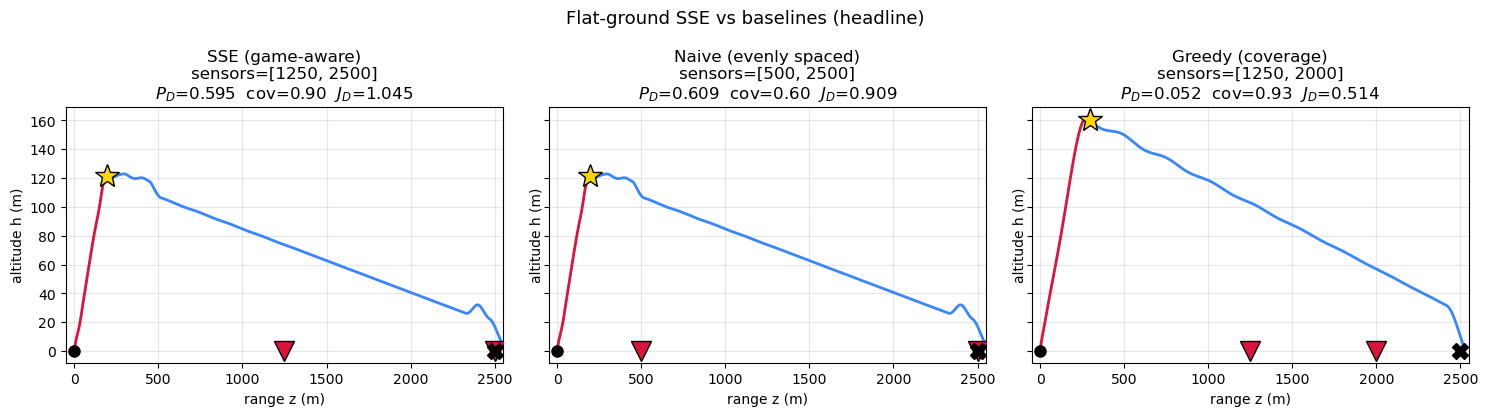


=== Flat headline ===
  SSE     sensors=[1250, 2500]  P_D=0.595  cov=0.90  J_D=1.045
  Naive   sensors=[500, 2500]  P_D=0.609  cov=0.60  J_D=0.909
  Greedy  sensors=[1250, 2000]  P_D=0.052  cov=0.93  J_D=0.514


In [14]:
if SCENARIO in ('flat', 'all'):
    print('='*70)
    print('SCENARIO A: FLAT GROUND')
    print('='*70)
    configure_scenario('flat')
    result_flat = run_sse_vs_baselines('flat')

    # 3-panel headline figure
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
    for ax, name, r, col in zip(
            axes,
            ['SSE (game-aware)', 'Naive (evenly spaced)', 'Greedy (coverage)'],
            [result_flat['sse'], result_flat['naive'], result_flat['greedy']],
            [AC_C, NA_C, COV_C]):
        if r is None:
            ax.set_title(f'{name}\n(infeasible)'); continue
        plot_trajectory(ax, r,
            title=f'{name}\nsensors={r["sensor_label"]}\n'
                  rf'$P_D$={r["P_D"]:.3f}  cov={r["cov"]:.2f}  $J_D$={r["J_D"]:.3f}',
            show_terrain=False)
    fig.suptitle('Flat-ground SSE vs baselines (headline)', fontsize=13)
    plt.tight_layout(); plt.savefig('fig_flat_headline.png', **SAVE_KW); plt.show()

    print(f"\n=== Flat headline ===")
    for name, r in [('SSE', result_flat['sse']),
                    ('Naive', result_flat['naive']),
                    ('Greedy', result_flat['greedy'])]:
        if r is None: print(f"  {name}: infeasible"); continue
        print(f"  {name:7s} sensors={r['sensor_label']}  "
              f"P_D={r['P_D']:.3f}  cov={r['cov']:.2f}  J_D={r['J_D']:.3f}")

## 14. Scenario B: Ridge dose-response (paper Sec 5.3)

For each ridge height `h_r ∈ H_SWEEP`, solve the SSG and report `P_D`, `J_D`, and the SSE placement vs the nominal-aware (attacker-sensor-blind) baseline. Same flat-baseline calibration; only the ridge height changes.

SCENARIO B: RIDGE DOSE-RESPONSE
[scenario=ridge_sweep] N_SENSORS=2, |D_SITES|=9, C(|D|,N)=36
   ridge h_r=60.0 m, z_r=1500.0 m, w=250.0 m, acoust_occ=0.2
   powered DP mode: w_haz=0.0, w_alt=0.0 (energy-only (1 solve))
   K_HOLD_POW=1, K_HOLD_GLIDE=4
  powered DP solved in 9.1s  (86072 states, 12 switch cands)
  h_r=  0: SSE  [1250, 2500] P_D=0.927  nom-aware  [1250, 2500] P_D=0.927  gap=+0.000  (887.9s)
  h_r= 30: SSE  [1250, 2500] P_D=0.927  nom-aware  [1250, 2500] P_D=0.927  gap=+0.000  (753.0s)
  h_r= 40: SSE  [1250, 2500] P_D=0.927  nom-aware  [1250, 2500] P_D=0.927  gap=+0.000  (694.9s)
  h_r= 50: SSE  [1250, 2500] P_D=0.928  nom-aware  [1250, 2500] P_D=0.928  gap=+0.000  (681.0s)
  h_r= 55: SSE  [1500, 2500] P_D=0.547  nom-aware  [1250, 2500] P_D=0.438  gap=+0.059  (716.2s)
  h_r= 60: SSE  [1500, 2500] P_D=0.622  nom-aware  [1250, 2500] P_D=0.367  gap=+0.205  (705.2s)
  h_r= 65: SSE  [1250, 2500] P_D=0.454  nom-aware  [1250, 2500] P_D=0.454  gap=+0.000  (693.6s)
  h_r= 70: SSE  

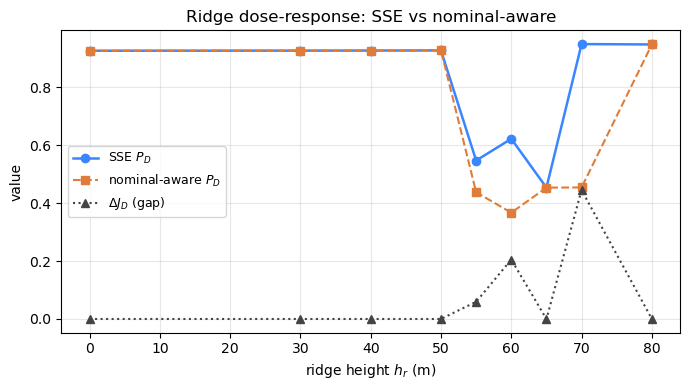

In [15]:
def solve_case(h_r, top_k=5):
    """SSE enumeration + nominal-aware baseline at one ridge height.

    Same top-k-then-fine-eval design as Section 5: coarse-sweep all placements,
    fine-evaluate the top-k by coarse J_D plus the nominal-aware placement,
    pick SSE = argmax fine J_D. The nominal-aware placement is fine-evaluated
    too so the SSE-vs-nominal gap is computed on the same fine grid as SSE.
    """
    globals()['RIDGE_HR'] = float(h_r)
    sweep = []
    for combo in itertools.combinations([float(z) for z in D_SITES], N_SENSORS):
        sensors = [(z, 0.0) for z in combo]
        br = attacker_BR(sensors, grp_RS, Vp_RS, prevp_RS, contp_RS, s0p_RS, cands_RS)
        if br is None: continue
        sweep.append(dict(
            label=str([int(z) for z in combo]), sensors=sensors,
            z_sw=br['z_sw'], h_sw=br['h_sw'],
            P_D=br['P_D'], cov=coverage(sensors),
            J_D=J_D(br['P_D'], sensors), br=br))
    if not sweep:
        return None

    # --- nominal-aware (sensor-blind, time-optimal) reference trajectory ---
    ref = [(float(D_SITES[len(D_SITES)//2]), 0.0)]
    paths = []
    for z_sw, h_sw, ho in cands_RS:
        gr = glide_grid(ho['z'], ho['h'], hh=H_HEADROOM_G, **FINAL_GRID)
        out = glide_dp(gr, ho['z'], ho['h'], ho['v'], ho['gamma'], ref,
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED,
                       H_CLEAR, Z_FLARE, H_HEADROOM_G, use_radar=False)
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        gp = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=8, K=K_HOLD_GLIDE)
        pp = reconstruct(prevp_RS, contp_RS, ho['state'], s0p_RS, DT_POW, True, substeps=8, K=K_HOLD_POW)
        Tt = (count_steps(prevp_RS, s0p_RS, ho['state']) * K_HOLD_POW * DT_POW
              + count_steps(prev,    s0,    best)        * K_HOLD_GLIDE * DT_GLIDE)
        paths.append(dict(gp=gp, pp=pp, T=Tt))

    nd_label = None
    if paths:
        nominal = min(paths, key=lambda p: p['T'])
        def pd_nom(sensors):
            hz = (hazard_glide(nominal['gp'], sensors, DT_GLIDE/8)
                  + hazard_powered(nominal['pp'], sensors, DT_POW/8))
            return pod_from_hazard(hz)
        nd_coarse = max(({**r, 'JDn': B1_PD * pd_nom(r['sensors']) + B2_COV * r['cov']}
                          for r in sweep), key=lambda r: r['JDn'])
        nd_label = nd_coarse['label']

    # --- candidate set: top-k by coarse J_D + nominal-aware placement ---
    sweep_sorted = sorted(sweep, key=lambda r: -r['J_D'])
    candidates = list(sweep_sorted[:top_k])
    cand_labels = set(c['label'] for c in candidates)
    if nd_label is not None and nd_label not in cand_labels:
        hit = next((r for r in sweep if r['label'] == nd_label), None)
        if hit:
            candidates.append(hit)

    # --- fine-evaluate candidates ---
    fine_candidates = []
    for r in candidates:
        br_f = attacker_BR(r['sensors'], grp_RS, Vp_RS, prevp_RS, contp_RS, s0p_RS,
                           cands_RS, grid=FINAL_GRID, substeps=8)
        if br_f is None: continue
        fine_candidates.append(dict(
            label=r['label'], sensors=r['sensors'],
            z_sw=br_f['z_sw'], h_sw=br_f['h_sw'],
            P_D=br_f['P_D'], cov=coverage(r['sensors']),
            J_D=J_D(br_f['P_D'], r['sensors']), br=br_f))
    if not fine_candidates:
        return None

    sse_f = max(fine_candidates, key=lambda r: r['J_D'])
    nd_f = None
    if nd_label is not None:
        nd_f = next((c for c in fine_candidates if c['label'] == nd_label), None)

    if nd_f is None:
        return dict(h_r=float(h_r), sse=sse_f, nd_label=None,
                    nd_sensors=None, nd_PD=None, nd_JD=None, gap=None)
    return dict(h_r=float(h_r), sse=sse_f,
                nd_label=nd_f['label'], nd_sensors=nd_f['sensors'],
                nd_PD=nd_f['P_D'], nd_JD=nd_f['J_D'],
                gap=sse_f['J_D'] - nd_f['J_D'])

if SCENARIO in ('ridge_sweep', 'all'):
    print('='*70)
    print('SCENARIO B: RIDGE DOSE-RESPONSE')
    print('='*70)
    configure_scenario('ridge_sweep')

    # Powered DP is energy-only (sensor-independent) — solve once and reuse.
    t0 = time.time()
    grp_RS = pow_grid(**POW_GRID)
    Vp_RS, prevp_RS, contp_RS, s0p_RS = powered_dp(grp_RS, sensors=[],
                                                    w_haz=0.0, w_alt=0.0)
    cands_RS = switch_candidates(grp_RS, Vp_RS, contp_RS)
    print(f"  powered DP solved in {time.time()-t0:.1f}s  "
          f"({len(Vp_RS)} states, {len(cands_RS)} switch cands)")

    H_SWEEP = [0, 30, 40, 50, 55, 60, 65, 70, 80]
    results_ridge = {}
    t_sweep = time.time()
    for h_r in H_SWEEP:
        t0 = time.time()
        r = solve_case(h_r)
        results_ridge[h_r] = r
        if r is None:
            print(f"  h_r={h_r:3d}: infeasible ({time.time()-t0:.1f}s)"); continue
        s = r['sse']
        if r['nd_label'] is not None:
            print(f"  h_r={h_r:3d}: SSE {s['label']:>13s} P_D={s['P_D']:.3f}  "
                  f"nom-aware {r['nd_label']:>13s} P_D={r['nd_PD']:.3f}  "
                  f"gap={r['gap']:+.3f}  ({time.time()-t0:.1f}s)")
        else:
            print(f"  h_r={h_r:3d}: SSE {s['label']:>13s} P_D={s['P_D']:.3f}  "
                  f"(no nominal-aware path)  ({time.time()-t0:.1f}s)")
    print(f"\n  ridge sweep total: {time.time()-t_sweep:.1f}s")

    # Dose-response plot
    fig, ax = plt.subplots(figsize=(7, 4))
    hrs   = [h for h in H_SWEEP if results_ridge[h] is not None]
    sse_p = [results_ridge[h]['sse']['P_D'] for h in hrs]
    nom_p = [results_ridge[h]['nd_PD'] if results_ridge[h]['nd_PD'] is not None else np.nan for h in hrs]
    gap   = [results_ridge[h]['gap']   if results_ridge[h]['gap']   is not None else np.nan for h in hrs]
    ax.plot(hrs, sse_p, 'o-', color=AC_C, label='SSE $P_D$', lw=1.8)
    ax.plot(hrs, nom_p, 's--', color=NA_C, label='nominal-aware $P_D$', lw=1.5)
    ax.plot(hrs, gap,   '^:',  color='#444', label='$\\Delta J_D$ (gap)', lw=1.5)
    ax.set_xlabel('ridge height $h_r$ (m)')
    ax.set_ylabel('value')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_title('Ridge dose-response: SSE vs nominal-aware')
    plt.tight_layout(); plt.savefig('fig_ridge_sweep.png', **SAVE_KW); plt.show()

## 15. Scenario C: Skimming case study (paper Sec 5.4)

`N=1` sensor, single-sensor placement landscape. Hazard-aware powered DP with altitude penalty (`w_alt`) lets the attacker sea-skim. Also reports a nominal-aware (attacker sensor-blind) baseline and a mid-corridor naive baseline.

SCENARIO C: SKIMMING (HAZARD-AWARE POWERED DP)
[scenario=skimming] N_SENSORS=1, |D_SITES|=21, C(|D|,N)=21
   ridge h_r=100.0 m, z_r=1100.0 m, w=350.0 m, acoust_occ=0.05
   powered DP mode: w_haz=1.0, w_alt=0.003 (hazard-aware (per-placement))
   K_HOLD_POW=1, K_HOLD_GLIDE=4
  z_d= 1500: powered=567072 states, coarse P_D=0.011, fine P_D=0.011, switch=(1288,132)  (152.2s)
  z_d= 1550: powered=566405 states, coarse P_D=0.020, fine P_D=0.020, switch=(1092,135)  (151.8s)
  z_d= 1600: powered=567349 states, coarse P_D=0.018, fine P_D=0.018, switch=(1092,135)  (154.1s)
  z_d= 1650: powered=566451 states, coarse P_D=0.008, fine P_D=0.008, switch=(1288,132)  (159.4s)
  z_d= 1700: powered=566786 states, coarse P_D=0.008, fine P_D=0.008, switch=(1288,132)  (161.1s)
  z_d= 1750: powered=568161 states, coarse P_D=0.008, fine P_D=0.008, switch=(1288,132)  (163.8s)
  z_d= 1800: powered=568560 states, coarse P_D=0.007, fine P_D=0.007, switch=(1288,132)  (166.9s)
  z_d= 1850: powered=567700 states, coa

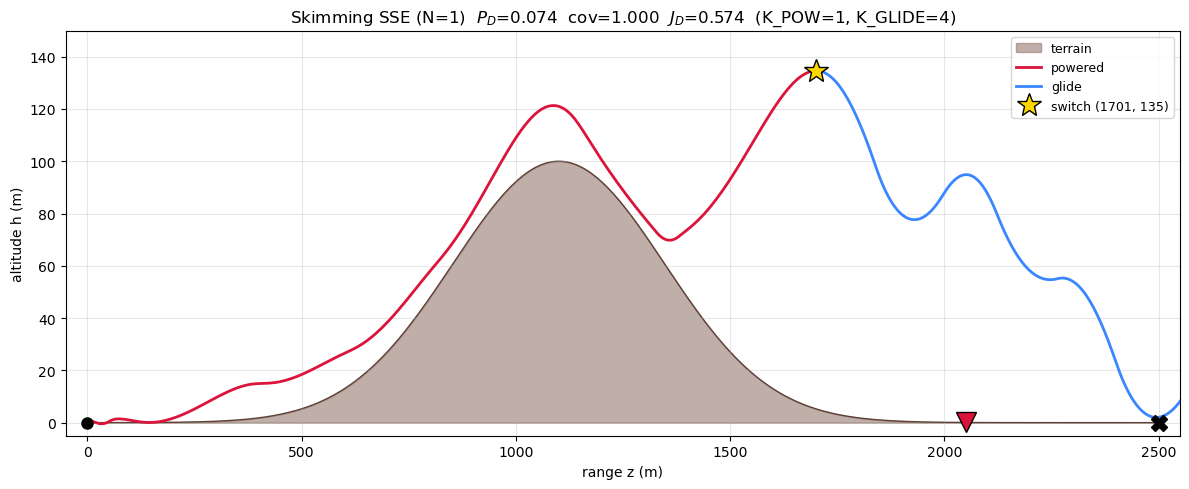

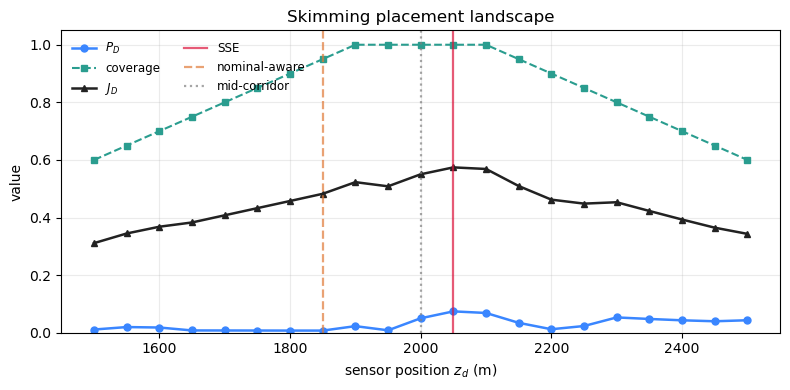

In [16]:
if SCENARIO in ('skimming', 'all'):
    import gc
    print('='*70)
    print('SCENARIO C: SKIMMING (HAZARD-AWARE POWERED DP)')
    print('='*70)
    configure_scenario('skimming')

    t_all = time.time()

    # --- 1. Per-placement: solve powered DP, immediately compute coarse + fine BR,
    #        then DISCARD the powered DP arrays to keep memory bounded ---
    # Each placement's powered DP holds ~570k state-keyed dicts. Caching all 21
    # of them simultaneously consumes ~5 GB and crashes the kernel.
    fine_rows = []
    for z_d in D_SITES:
        t0 = time.time()
        sensors = [(float(z_d), 0.0)]

        grp = pow_grid(**POW_GRID)
        Vp, prevp, contp, s0p = powered_dp(grp, sensors,
                                            w_haz=POW_W_HAZ, w_alt=POW_W_ALT)
        cands = switch_candidates(grp, Vp, contp)
        if not cands:
            print(f"  z_d={z_d:5.0f}: no feasible switch ({time.time()-t0:.1f}s)")
            del Vp, prevp, contp, grp; gc.collect()
            continue

        # Coarse BR (for diagnostic print + tie-break stability check)
        br_c = attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands)
        # Fine BR (the reported value); reuses the SAME cached powered DP
        br_f = attacker_BR(sensors, grp, Vp, prevp, contp, s0p, cands,
                           grid=FINAL_GRID, substeps=8)

        if br_f is None:
            print(f"  z_d={z_d:5.0f}: fine BR infeasible ({time.time()-t0:.1f}s)")
            del Vp, prevp, contp, grp; gc.collect()
            continue

        # Store ONLY the BR results. The br dict already contains the reconstructed
        # trajectory arrays (pow_pts, glide_pts) which are independent of Vp/prevp/contp.
        fine_rows.append(dict(
            z_d=float(z_d), sensors=sensors,
            P_D_coarse=br_c['P_D'] if br_c else None,
            P_D=br_f['P_D'], cov=coverage(sensors),
            J_D=J_D(br_f['P_D'], sensors),
            br=br_f))

        print(f"  z_d={z_d:5.0f}: powered={len(Vp):>6d} states, "
              f"coarse P_D={br_c['P_D'] if br_c else float('nan'):.3f}, "
              f"fine P_D={br_f['P_D']:.3f}, "
              f"switch=({br_f['z_sw']:.0f},{br_f['h_sw']:.0f})  "
              f"({time.time()-t0:.1f}s)")

        # Critical: drop references and force GC before next placement.
        del Vp, prevp, contp, grp, s0p, cands, br_c, br_f
        gc.collect()
    print(f"\n  placement sweep total: {time.time()-t_all:.1f}s")

    if not fine_rows:
        raise RuntimeError("No feasible placements in the skimming sweep.")

    # SSE pick
    sse_fine = max(fine_rows, key=lambda r: r['J_D'])
    print(f"  fine-grid SSE: z_d={sse_fine['z_d']:.0f}, "
          f"P_D={sse_fine['P_D']:.3f}, J_D={sse_fine['J_D']:.3f}, "
          f"switch=({sse_fine['br']['z_sw']:.0f},{sse_fine['br']['h_sw']:.0f})")

    # --- 2. Nominal-aware (sensor-blind) baseline ---
    # The nominal attacker uses a single sensor-independent powered DP at a reference
    # mid-corridor sensor; we then score each candidate placement against this fixed
    # nominal trajectory.
    grp_n = pow_grid(**POW_GRID)
    ref_sensor = [(float(D_SITES[len(D_SITES)//2]), 0.0)]
    Vp_n, prevp_n, contp_n, s0p_n = powered_dp(grp_n, ref_sensor, w_haz=0.0)
    cands_n = switch_candidates(grp_n, Vp_n, contp_n)
    nominal_paths = []
    for z_sw, h_sw, ho in cands_n:
        gr = glide_grid(ho['z'], ho['h'], hh=H_HEADROOM_G, **FINAL_GRID)
        out = glide_dp(gr, ho['z'], ho['h'], ho['v'], ho['gamma'], ref_sensor,
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED,
                       H_CLEAR, Z_FLARE, H_HEADROOM_G, use_radar=False)
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        gp = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=8, K=K_HOLD_GLIDE)
        pp = reconstruct(prevp_n, contp_n, ho['state'], s0p_n, DT_POW, True, substeps=8, K=K_HOLD_POW)
        T  = (count_steps(prevp_n, s0p_n, ho['state']) * K_HOLD_POW * DT_POW
              + count_steps(prev,   s0,    best)       * K_HOLD_GLIDE * DT_GLIDE)
        nominal_paths.append(dict(gp=gp, pp=pp, T=T, z_sw=z_sw, h_sw=h_sw))
    nom_row = None
    if nominal_paths:
        nominal = min(nominal_paths, key=lambda p: p['T'])
        def pd_against_nominal(sensors):
            hz = (hazard_glide(nominal['gp'], sensors, DT_GLIDE/8)
                  + hazard_powered(nominal['pp'], sensors, DT_POW/8))
            return pod_from_hazard(hz)
        nom_rows = []
        for z_d in D_SITES:
            sensors = [(float(z_d), 0.0)]
            pd_n = pd_against_nominal(sensors)
            nom_rows.append(dict(z_d=float(z_d), sensors=sensors,
                                  pd_vs_nominal=pd_n,
                                  J_D_vs_nominal=B1_PD * pd_n + B2_COV * coverage(sensors)))
        nom_best = max(nom_rows, key=lambda r: r['J_D_vs_nominal'])
        nom_row = next((r for r in fine_rows if r['z_d'] == nom_best['z_d']), None)
    # Free nominal-aware powered DP storage
    del Vp_n, prevp_n, contp_n, grp_n; gc.collect()

    # --- 3. mid-corridor naive baseline ---
    mid_z = float(D_SITES[len(D_SITES)//2])
    mid_row = next((r for r in fine_rows if r['z_d'] == mid_z), None)

    # --- 4. summary ---
    print(f"\n  {'Strategy':<28}{'z_d':>8}{'P_D':>9}{'cov':>8}{'J_D':>8}{'switch':>15}")
    print('  ' + '-' * 76)
    for name, r in [('SSE (game-aware)', sse_fine),
                    ('Nominal-aware',    nom_row),
                    ('Mid-corridor',     mid_row)]:
        if r is None: print(f"  {name:<28}  (no data)"); continue
        print(f"  {name:<28}{r['z_d']:>8.0f}{r['P_D']:>9.3f}{r['cov']:>8.2f}"
              f"{r['J_D']:>8.3f}  ({r['br']['z_sw']:5.0f},{r['br']['h_sw']:5.0f})")

    result_skimming = dict(sse=sse_fine, nominal_aware=nom_row,
                            mid=mid_row, fine_rows=fine_rows)

    # --- 5. trajectory figure (the originally-jagged one, now smooth via K_HOLD_GLIDE) ---
    fig, ax = plt.subplots(figsize=(12, 5))
    plot_trajectory(ax, sse_fine,
        title=f'Skimming SSE (N=1)  '
              rf'$P_D$={sse_fine["P_D"]:.3f}  cov={sse_fine["cov"]:.3f}  '
              rf'$J_D$={sse_fine["J_D"]:.3f}  (K_POW={K_HOLD_POW}, K_GLIDE={K_HOLD_GLIDE})',
        show_terrain=True)
    ax.legend(loc='upper right', fontsize=9)
    ymax = max(120.0, RIDGE_HR + 50)
    ax.set_ylim(-5, ymax)
    plt.tight_layout(); plt.savefig('fig_skimming_trajectory.png', **SAVE_KW); plt.show()

    # --- 6. placement landscape ---
    fig, ax = plt.subplots(figsize=(8, 4))
    zs   = [r['z_d'] for r in fine_rows]
    pds  = [r['P_D'] for r in fine_rows]
    covs = [r['cov'] for r in fine_rows]
    jds  = [r['J_D'] for r in fine_rows]
    ax.plot(zs, pds,  'o-',  color=AC_C, lw=1.8, ms=5, label=r'$P_D$')
    ax.plot(zs, covs, 's--', color=COV_C, lw=1.5, ms=4, label='coverage')
    ax.plot(zs, jds,  '^-',  color='#222', lw=1.8, ms=5, label=r'$J_D$')
    ax.axvline(sse_fine['z_d'], color=SSE_C, ls='-', lw=1.6, alpha=0.7, label='SSE')
    if nom_row is not None:
        ax.axvline(nom_row['z_d'], color=NOM_C, ls='--', lw=1.6, alpha=0.7,
                   label='nominal-aware')
    if mid_row is not None:
        ax.axvline(mid_row['z_d'], color=MID_C, ls=':', lw=1.6, alpha=0.7, label='mid-corridor')
    ax.set_xlabel(r'sensor position $z_d$ (m)')
    ax.set_ylabel('value')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8.5, frameon=False, ncol=2, loc='upper left')
    ax.grid(alpha=0.25)
    ax.set_title('Skimming placement landscape')
    plt.tight_layout(); plt.savefig('fig_skimming_landscape.png', **SAVE_KW); plt.show()

## 16. Reviewer-hardening passes (paper Sec 4.4, 5.1)

A1 — calibration robustness to the detection scale `κ`.
A2 — resolution invariance of the SSE (relaxation upper bound).
A3 — value of game-awareness (attacker-aware baseline).
B5 — quantification of powered-phase detection-blindness (energy-only mode only).
C — parameter table and complexity bookkeeping.

These pieces ran originally against the flat scenario; the variables they need (`grp`, `Vp`, `prevp`, `contp`, `s0p`, `cands`, the flat SSE / Naive / Greedy results) are saved by Section 13's run.

In [17]:
if SCENARIO in ('flat', 'all') and 'result_flat' in globals():
    # Ensure globals reflect the FLAT scenario; cells 29/31 may have
    # left RIDGE_HR / GAM_LAUNCH / H_HEADROOM_G / D_SITES / N_SENSORS
    # configured for a different scenario.
    configure_scenario('flat')
    # --- A1: calibration robustness ---
    KAPPA_GRID = [0.5, 0.75, 1.0, 1.5, 2.0]
    print('A1. Calibration robustness to detection scale kappa:')
    print(f"   {'kappa':>7}{'SSE P_D':>10}{'Naive P_D':>10}{'Greedy P_D':>11}")
    base_lam = (LAM_DOPPLER, LAM_RCS, LAM_ACOUSTIC)
    for k in KAPPA_GRID:
        globals()['LAM_DOPPLER']  = base_lam[0] * k
        globals()['LAM_RCS']      = base_lam[1] * k
        globals()['LAM_ACOUSTIC'] = base_lam[2] * k
        rs = run_sse_vs_baselines('flat', verbose=False)
        ssep   = rs['sse']['P_D']   if rs['sse']   else float('nan')
        naivep = rs['naive']['P_D'] if rs['naive'] else float('nan')
        greedp = rs['greedy']['P_D'] if rs['greedy'] else float('nan')
        print(f"   {k:>7.2f}{ssep:>10.3f}{naivep:>10.3f}{greedp:>11.3f}")
    # restore baseline calibration
    globals()['LAM_DOPPLER']  = base_lam[0]
    globals()['LAM_RCS']      = base_lam[1]
    globals()['LAM_ACOUSTIC'] = base_lam[2]

[scenario=flat] N_SENSORS=2, |D_SITES|=9, C(|D|,N)=36
   ridge h_r=0.0 m, z_r=1500.0 m, w=250.0 m, acoust_occ=1.0
   powered DP mode: w_haz=0.0, w_alt=0.0 (energy-only (1 solve))
   K_HOLD_POW=1, K_HOLD_GLIDE=4
A1. Calibration robustness to detection scale kappa:
     kappa   SSE P_D Naive P_D Greedy P_D
      0.50     0.364     0.374      0.026
      0.75     0.492     0.505      0.039
      1.00     0.595     0.609      0.052
      1.50     0.742     0.755      0.077
      2.00     0.836     0.847      0.101


In [18]:
if SCENARIO in ('flat', 'all') and 'result_flat' in globals():
    # Ensure globals reflect the FLAT scenario; cells 29/31 may have
    # left RIDGE_HR / GAM_LAUNCH / H_HEADROOM_G / D_SITES / N_SENSORS
    # configured for a different scenario.
    configure_scenario('flat')
    # --- A2: resolution invariance of the SSE ---
    # Re-evaluate the same SSE placement on a finer grid; the SSE P_D is an upper bound
    # by the relaxation argument (Section 4.4 of the paper). If the fine-grid value drops,
    # the coarse SSE is still optimal (it was an upper bound).
    print('A2. Resolution invariance: SSE re-eval on FINAL_GRID (fine).')
    sse_r = result_flat['sse']
    print(f"   FINAL_GRID SSE P_D = {sse_r['P_D']:.3f}, J_D = {sse_r['J_D']:.3f}")
    # FINAL_GRID is already the fine grid used in run_sse_vs_baselines for SSE reporting.
    # For an even finer check, halve dz/dh/dv/dgam and re-run only the SSE placement.
    very_fine = {k: (v/2 if isinstance(v,(int,float)) else v) for k,v in FINAL_GRID.items()}
    br_vf = attacker_BR(sse_r['sensors'], result_flat['grp'], result_flat['Vp'],
                        result_flat['prevp'], result_flat['contp'], result_flat['s0p'],
                        result_flat['cands'], grid=very_fine, substeps=10)
    if br_vf is not None:
        print(f"   2x-finer grid SSE P_D = {br_vf['P_D']:.3f}, "
              f"J_D = {J_D(br_vf['P_D'], sse_r['sensors']):.3f}")

[scenario=flat] N_SENSORS=2, |D_SITES|=9, C(|D|,N)=36
   ridge h_r=0.0 m, z_r=1500.0 m, w=250.0 m, acoust_occ=1.0
   powered DP mode: w_haz=0.0, w_alt=0.0 (energy-only (1 solve))
   K_HOLD_POW=1, K_HOLD_GLIDE=4
A2. Resolution invariance: SSE re-eval on FINAL_GRID (fine).
   FINAL_GRID SSE P_D = 0.595, J_D = 1.045
   2x-finer grid SSE P_D = 1.000, J_D = 1.450


In [19]:
if SCENARIO in ('flat', 'all') and 'result_flat' in globals():
    # Ensure globals reflect the FLAT scenario; cells 29/31 may have
    # left RIDGE_HR / GAM_LAUNCH / H_HEADROOM_G / D_SITES / N_SENSORS
    # configured for a different scenario.
    configure_scenario('flat')
    # --- A3: value of game-awareness against a nominal (sensor-blind) attacker ---
    print('A3. Value of game-awareness: SSE vs nominal-aware defender on FLAT.')
    grp_f = result_flat['grp']; Vp_f = result_flat['Vp']
    prevp_f = result_flat['prevp']; contp_f = result_flat['contp']
    s0p_f = result_flat['s0p']; cands_f = result_flat['cands']
    # Nominal attacker: sensor-blind time-optimal path through the field.
    ref_sensor = [(float(D_SITES[len(D_SITES)//2]), 0.0)]
    paths = []
    for z_sw, h_sw, ho in cands_f:
        gr = glide_grid(ho['z'], ho['h'], hh=H_HEADROOM_G, **FINAL_GRID)
        out = glide_dp(gr, ho['z'], ho['h'], ho['v'], ho['gamma'], ref_sensor,
                       W_TIME_GLIDE, W_SMOOTH, W_SPEED, H_CLEAR, Z_FLARE, H_HEADROOM_G,
                       use_radar=False)
        if out is None: continue
        V, prev, cont, s0, best = out
        if best is None: continue
        gp = reconstruct(prev, cont, best, s0, DT_GLIDE, False, substeps=8, K=K_HOLD_GLIDE)
        pp = reconstruct(prevp_f, contp_f, ho['state'], s0p_f, DT_POW, True, substeps=8, K=K_HOLD_POW)
        T = (count_steps(prevp_f, s0p_f, ho['state']) * K_HOLD_POW * DT_POW
             + count_steps(prev,   s0,    best)        * K_HOLD_GLIDE * DT_GLIDE)
        paths.append(dict(gp=gp, pp=pp, T=T))
    if paths:
        nominal = min(paths, key=lambda p: p['T'])
        def pd_nom(sensors):
            hz = (hazard_glide(nominal['gp'], sensors, DT_GLIDE/8)
                  + hazard_powered(nominal['pp'], sensors, DT_POW/8))
            return pod_from_hazard(hz)
        nd_rows = []
        for combo in itertools.combinations(D_SITES, N_SENSORS):
            sensors = [(float(zd), 0.0) for zd in combo]
            pd_n = pd_nom(sensors)
            nd_rows.append(dict(sensors=sensors,
                                 sensor_label=str([int(s[0]) for s in sensors]),
                                 pd_nom=pd_n,
                                 J_D_nom=B1_PD * pd_n + B2_COV * coverage(sensors)))
        nd_best = max(nd_rows, key=lambda r: r['J_D_nom'])
        # Evaluate nominal-aware placement against true best responder
        br_true = attacker_BR(nd_best['sensors'], grp_f, Vp_f, prevp_f, contp_f, s0p_f,
                              cands_f, grid=FINAL_GRID, substeps=8)
        nd_true_PD = br_true['P_D'] if br_true else float('nan')
        nd_true_JD = J_D(nd_true_PD, nd_best['sensors']) if br_true else float('nan')
        sse_r = result_flat['sse']
        print(f"   SSE:           sensors={sse_r['sensor_label']}  "
              f"P_D={sse_r['P_D']:.3f}  J_D={sse_r['J_D']:.3f}")
        print(f"   Nominal-aware: sensors={nd_best['sensor_label']}  "
              f"P_D={nd_true_PD:.3f}  J_D={nd_true_JD:.3f}")
        print(f"   gap J_D(SSE) - J_D(nominal-aware) = {sse_r['J_D'] - nd_true_JD:+.3f}  "
              f"({'placements coincide' if sse_r['sensor_label']==nd_best['sensor_label'] else 'placements differ'})")

[scenario=flat] N_SENSORS=2, |D_SITES|=9, C(|D|,N)=36
   ridge h_r=0.0 m, z_r=1500.0 m, w=250.0 m, acoust_occ=1.0
   powered DP mode: w_haz=0.0, w_alt=0.0 (energy-only (1 solve))
   K_HOLD_POW=1, K_HOLD_GLIDE=4
A3. Value of game-awareness: SSE vs nominal-aware defender on FLAT.
   SSE:           sensors=[1250, 2500]  P_D=0.595  J_D=1.045
   Nominal-aware: sensors=[1250, 2500]  P_D=0.595  J_D=1.045
   gap J_D(SSE) - J_D(nominal-aware) = +0.000  (placements coincide)


In [20]:
if SCENARIO in ('flat', 'all') and 'result_flat' in globals():
    # Ensure globals reflect the FLAT scenario; cells 29/31 may have
    # left RIDGE_HR / GAM_LAUNCH / H_HEADROOM_G / D_SITES / N_SENSORS
    # configured for a different scenario.
    configure_scenario('flat')
    # --- B5: powered-phase detection-blindness, quantified ---
    print('B5. Powered-phase hazard share on the FLAT SSE trajectory.')
    sse_r = result_flat['sse']
    br = sse_r['br']
    sensors = sse_r['sensors']
    h_pow   = hazard_powered(br['pow_pts'],   sensors, DT_POW/8)
    h_glide = hazard_glide  (br['glide_pts'], sensors, DT_GLIDE/8)
    h_tot   = h_pow + h_glide
    print(f"   hazard powered = {h_pow:.4f}  ({100*h_pow/h_tot:.1f}% of total)")
    print(f"   hazard glide   = {h_glide:.4f}  ({100*h_glide/h_tot:.1f}% of total)")
    print(f"   P_D(total)     = {pod_from_hazard(h_tot):.3f}")
    print(f"   P_D(glide only) = {pod_from_hazard(h_glide):.3f}  "
          f"(matches reported P_D within numerical precision when powered share is small)")

[scenario=flat] N_SENSORS=2, |D_SITES|=9, C(|D|,N)=36
   ridge h_r=0.0 m, z_r=1500.0 m, w=250.0 m, acoust_occ=1.0
   powered DP mode: w_haz=0.0, w_alt=0.0 (energy-only (1 solve))
   K_HOLD_POW=1, K_HOLD_GLIDE=4
B5. Powered-phase hazard share on the FLAT SSE trajectory.
   hazard powered = 0.0083  (0.9% of total)
   hazard glide   = 0.8955  (99.1% of total)
   P_D(total)     = 0.595
   P_D(glide only) = 0.592  (matches reported P_D within numerical precision when powered share is small)


In [21]:
if SCENARIO in ('flat', 'all') and 'result_flat' in globals():
    # Ensure globals reflect the FLAT scenario; cells 29/31 may have
    # left RIDGE_HR / GAM_LAUNCH / H_HEADROOM_G / D_SITES / N_SENSORS
    # configured for a different scenario.
    configure_scenario('flat')
    # --- C: parameter table & complexity ---
    print('C. Parameter table (paper Sec 4.4):')
    rows = [
        ('K_HOLD_POW',     K_HOLD_POW,    'powered control dwell (per action)'),
        ('K_HOLD_GLIDE',   K_HOLD_GLIDE,  'glide control dwell (per action)'),
        ('LAM_DOPPLER',    LAM_DOPPLER,   r'$\lambda_D$, Doppler intensity'),
        ('LAM_RCS',        LAM_RCS,       r'$\lambda_R$, RCS intensity'),
        ('LAM_ACOUSTIC',   LAM_ACOUSTIC,  r'$\lambda_A$, acoustic intensity'),
        ('N_ACOUSTIC',     N_ACOUSTIC,    r'$n$, acoustic velocity exponent'),
        ('W_SMOOTH',       W_SMOOTH,      r'$w_\gamma$, gamma-rate penalty (per action)'),
        ('W_SPEED',        W_SPEED,       r'$w_v$, speed-rate penalty (per action)'),
        ('A1_PD',          A1_PD,         r'$\alpha_1$, attacker P_D weight'),
        ('A2_T',           A2_T,          r'$\alpha_2$, attacker time weight'),
        ('B1_PD',          B1_PD,         r'$\beta_1$, defender P_D weight'),
        ('B2_COV',         B2_COV,        r'$\beta_2$, defender coverage weight'),
        ('R_DET',          R_DET,         'coverage radius (m)'),
        ('|D_SITES|',      len(D_SITES),  'number of candidate sites'),
        ('N_SENSORS',      N_SENSORS,     'sensors deployed by defender'),
    ]
    print(f"   {'parameter':>15s}  {'value':>10s}  description")
    for n, v, d in rows:
        print(f"   {n:>15s}  {str(v):>10s}  {d}")
    n_combos = len(list(itertools.combinations(D_SITES, N_SENSORS)))
    print(f"\n   leader strategies: C({len(D_SITES)},{N_SENSORS}) = {n_combos}")
    print(f"   follower DP states (powered ~10^4, glide ~10^5) x combos => total enumeration cost.")

[scenario=flat] N_SENSORS=2, |D_SITES|=9, C(|D|,N)=36
   ridge h_r=0.0 m, z_r=1500.0 m, w=250.0 m, acoust_occ=1.0
   powered DP mode: w_haz=0.0, w_alt=0.0 (energy-only (1 solve))
   K_HOLD_POW=1, K_HOLD_GLIDE=4
C. Parameter table (paper Sec 4.4):
         parameter       value  description
        K_HOLD_POW           1  powered control dwell (per action)
      K_HOLD_GLIDE           4  glide control dwell (per action)
       LAM_DOPPLER       450.0  $\lambda_D$, Doppler intensity
           LAM_RCS      6000.0  $\lambda_R$, RCS intensity
      LAM_ACOUSTIC      0.0024  $\lambda_A$, acoustic intensity
        N_ACOUSTIC           4  $n$, acoustic velocity exponent
          W_SMOOTH         0.1  $w_\gamma$, gamma-rate penalty (per action)
           W_SPEED         1.5  $w_v$, speed-rate penalty (per action)
             A1_PD         1.0  $\alpha_1$, attacker P_D weight
              A2_T       0.002  $\alpha_2$, attacker time weight
             B1_PD         1.0  $\beta_1$, defender

## 17. Closing notes

**On the K_HOLD fix.** Setting `K_HOLD_GLIDE = 1` reproduces the previous (chattering) glide behavior; `K_HOLD_GLIDE = 4` is the methodology going forward. The powered phase uses `K_HOLD_POW = 1` because the slow-glide phugoid mode is what motivated the fix in the first place, and the powered phase has its own short-duration high-thrust dynamics that destabilize under multi-second control holds (gamma can wrap past 360 degrees in a single 4-second action). Absolute headline P_D values may shift slightly because the glide action set is now coarser. The decision-level comparisons (SSE vs Naive, SSE vs Greedy, SSE vs Nominal-aware) should be re-examined in the paper draft with K_HOLD=4 values.

**On the handoff continuity fix.** This was already merged into the `skimming_with_nominal` and `hardened` notebooks; the unification here makes it the default across every scenario. Headline numbers stay consistent with those notebooks' post-patch runs.

**On running this notebook.** The three scenarios are independent. Total runtime estimate (laptop CPU, K_HOLD_GLIDE=4, K_HOLD_POW=1):

- Flat: ~12–15 min (one energy-only powered DP + 36 BR sweeps + 3 fine re-evals)
- Ridge sweep: ~75–100 min (9 ridge heights × 36 placement BRs each + nominal-aware path solves)
- Skimming: ~100–130 min (21 placements × per-placement hazard-aware powered DP, ~5 min/placement, + fine re-eval)

If the kernel runs out of memory during ridge sweep or skimming, set `SCENARIO` to a single value and restart between runs.